In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
df = pd.read_csv("mushrooms.csv")

print("Shape:", df.shape)
df.head()

for col in df.columns:
    if (df[col] == '?').any():
        print(f"Column '{col}' has {(df[col]=='?').sum()} '?' entries")


encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()


Shape: (8124, 23)
Column 'stalk-root' has 2480 '?' entries


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,0,3,2,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,0,2,2,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,0,2,2,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,0,3,2,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,1,3,2,2,7,7,0,2,1,0,3,0,1


In [2]:
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", dict(zip(encoders['class'].classes_, encoders['class'].transform(encoders['class'].classes_))))

X shape: (8124, 22)
y shape: (8124,)
Target classes: {'e': np.int64(0), 'p': np.int64(1)}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean (~0):", X_train_scaled.mean().round(3))
print("Scaled training data std (~1):", X_train_scaled.std().round(3))

Train shape: (6499, 22)
Test shape: (1625, 22)
Scaled training data mean (~0): 0.0
Scaled training data std (~1): 0.977


data preparing is the same as before as its the same dataset ( couldnt find the link for the supposednly new data set y3m)

In [4]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

learning_rates = np.round(np.arange(0.001, 1.001, 0.001), 3)
print("Number of learning rates to test:", len(learning_rates))

Number of learning rates to test: 1000


In [5]:
# train Logistic Regression (via SGD) for each llearning rate
train_f1_scores = []
test_f1_scores = []

for lr in learning_rates:
    model = SGDClassifier(
        loss='log_loss',        # log reg
        learning_rate='constant',
        eta0=lr,
        max_iter=1000,
        tol=None,               
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

print("Done training for all learning rates")

Done training for all learning rates


In [6]:
results_df = pd.DataFrame({
    'Learning_Rate': learning_rates,
    'Train_F1': train_f1_scores,
    'Test_F1': test_f1_scores
})

results_df.head(10)

best_row = results_df.loc[results_df['Test_F1'].idxmax()]
print("Best learning rate by test F1-score:", best_row['Learning_Rate'])
print("Test F1 at that rate:", round(best_row['Test_F1'], 4))

Best learning rate by test F1-score: 0.003
Test F1 at that rate: 0.9634


lol 29 mins training


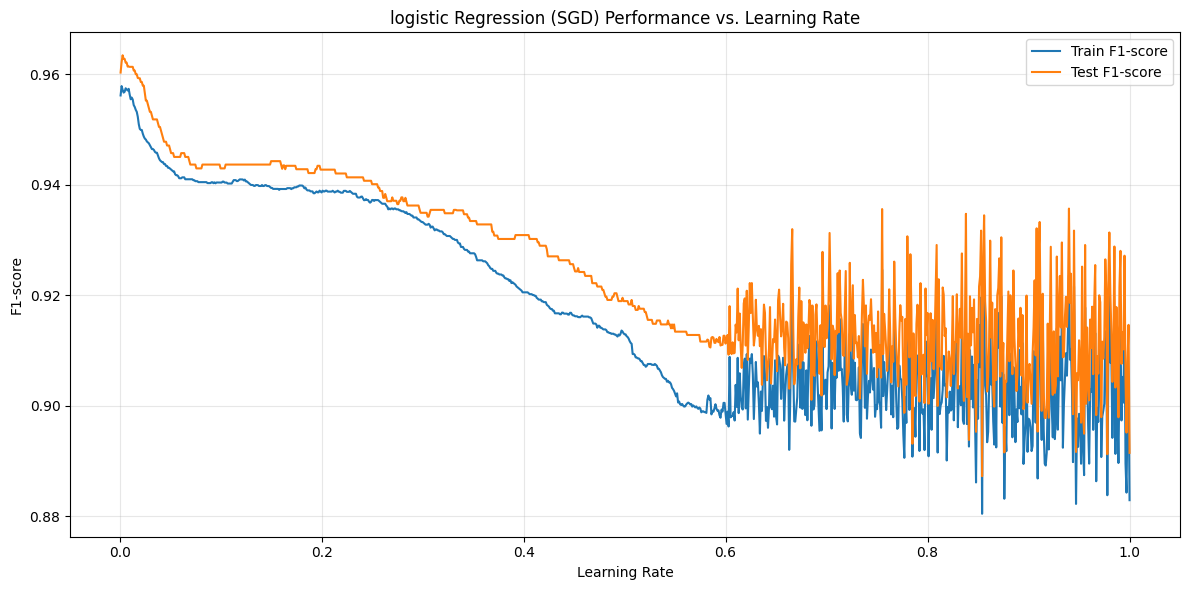

In [7]:

plt.figure(figsize=(12, 6))
plt.plot(results_df['Learning_Rate'], results_df['Train_F1'], label='Train F1-score', linewidth=1.5)
plt.plot(results_df['Learning_Rate'], results_df['Test_F1'], label='Test F1-score', linewidth=1.5)

plt.xlabel('Learning Rate')
plt.ylabel('F1-score')
plt.title('logistic Regression (SGD) Performance vs. Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

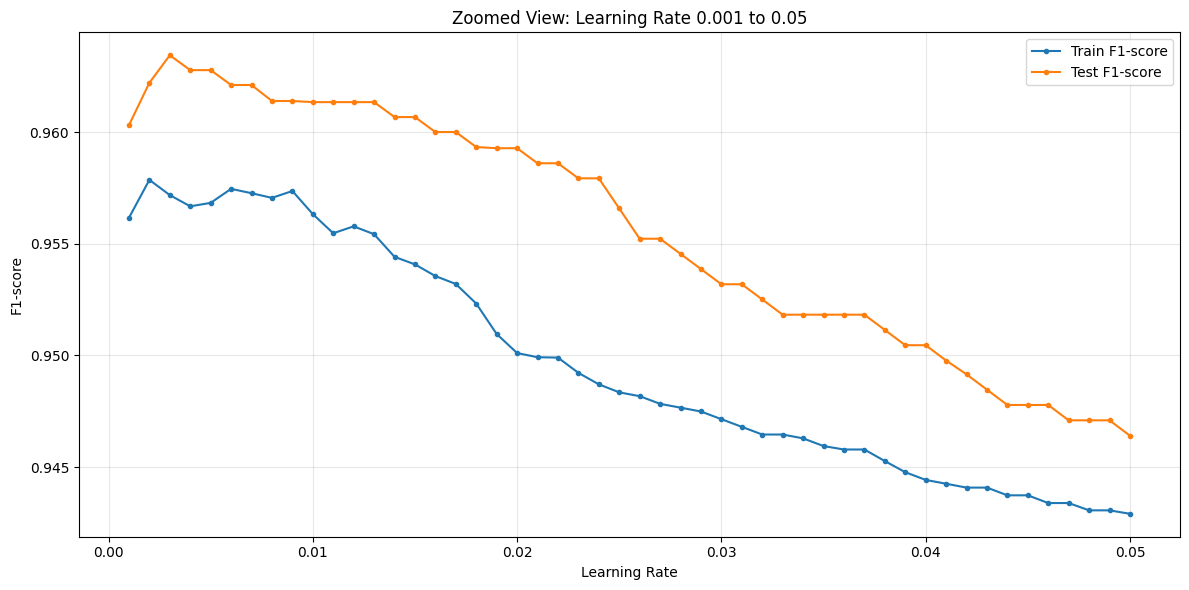

In [8]:
plt.figure(figsize=(12, 6))
zoom = results_df[results_df['Learning_Rate'] <= 0.05]

plt.plot(zoom['Learning_Rate'], zoom['Train_F1'], marker='.', label='Train F1-score')
plt.plot(zoom['Learning_Rate'], zoom['Test_F1'], marker='.', label='Test F1-score')

plt.xlabel('Learning Rate')
plt.ylabel('F1-score')
plt.title('Zoomed View: Learning Rate 0.001 to 0.05')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Analysis:

Test F1-score peaked at 0.9634 with a learning rate of 0.003, the best result across the full sweep from 0.001 to 1.000.

Small learning rates (0.001–0.01) allowed the model to converge steadily to a strong solution, with train and test scores closely aligned.

As the learning rate increased, F1-score declined smoothly, showing progressively worse convergence rather than overfitting.

Above a learning rate of roughly 0.6, both train and test F1 became highly unstable, oscillating sharply — a sign of SGD divergence from overshooting the minimum.

Since train and test performance tracked each other throughout, the learning rate affected optimization quality, not generalization — a small learning rate (~0.001–0.01) is recommended for stable, high-performing training.